In [1]:
import nibabel as nib
from glob import glob
import os
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
import numpy as np
import math


In [2]:
SOURCE_IMG = "data/images/*"
SOURCE_LABELS = 'data/labels/*'

In [3]:
# view number of classes in labels
img = nib.load('./data/labels/liver_0.nii.gz').get_fdata()
np.unique(img)

array([0., 1., 2.])

In [4]:
# shape of training data, objective: check if number of slices are uniform
# output = (x, y, slice_index) --> (x,y) gives pixel structure, each pixel has a physical width and height, whereas slice_index gives which slice it is.
# CT scans are like stack of bread slices, (x,y) = width * height of one slice, slice_index = which slice it is
# Depending on machine configuration, space between slices(z_spacing) may be different(img.header.get_zooms()-> (x_spacing, y_spacing, z_spacing)
# x_spacing = mm per moving 1px left to right
# y_spacing = mm per moving 1px up to down
images = sorted(glob('data/labels/*.nii.gz'))
for image in images:
    img_data = nib.load(image).get_fdata()
    print(img_data.shape)

(512, 512, 75)
(512, 512, 123)
(512, 512, 517)


In [5]:

# Step1: find minimum number of slices, also, given the model architecture the sample dimension should be multiple of 16
# images = glob(SOURCE_IMG)
# min_slices = min(nib.load(image).shape[2] for image in images)
min_slices = 64

In [6]:
# Step2: save those slices in new folder
SOURCE_DATASET_IMG = 'dataset/train/images'
SOURCE_DATASET_LABELS = 'dataset/train/labels'
SOURCE_DATASET_TEST = 'dataset/test'
Path(SOURCE_DATASET_IMG).mkdir(parents=True, exist_ok=True)
Path(SOURCE_DATASET_LABELS).mkdir(parents=True, exist_ok=True)
images = sorted(glob(SOURCE_IMG))

for image in images:
    img = nib.load(image)
    img_data = img.get_fdata()
    cropped_img_data = img_data[:,:, :min_slices]
    cropped_img = nib.Nifti1Image(
        cropped_img_data,
        img.affine,
        img.header
    )
    cropped_img.header['scl_slope'] = 1.0
    cropped_img.header['scl_inter'] = 0.0

    output_file = os.path.join(SOURCE_DATASET_IMG, Path(image).name)
    nib.save(cropped_img, output_file)
    print(f"{Path(image).name}: {img_data.shape} -> {cropped_img_data.shape}")

liver_0.nii.gz: (512, 512, 75) -> (512, 512, 64)
liver_1.nii.gz: (512, 512, 123) -> (512, 512, 64)
liver_2.nii.gz: (512, 512, 517) -> (512, 512, 64)


In [7]:
# Step2: save those labels in new folder
# ISSUE1: changes label values into float, not exactly 0,1,2. Why?
# ISSUE2: loads first 64 slices of every sample, this may miss informative labels and images
# ISSUE3: ct scan has different configurations (slice_spacing). So, taking first 64 slices of two images may cover 50cm in one image and 100cm in other image, 
    # giving different physical volumes of anatomical structure. (also, model may use slice_index as location of liver, if most image has positive labels in that slice, then it may learn that dimension has liver on another image)

# SOLUTION1: Resample into same physical space(1mm, 1mm, 1mm), then crop or resize to uniform dimension (512, 512, 64)
labels = sorted(glob(SOURCE_LABELS))
for image in labels:
    img = nib.load(image)
    img_data = img.get_fdata()
    cropped_img_data = img_data[:,:, :min_slices]
    # cast to clean integer labels before saving
    # cropped_img_data = np.round(cropped_img_data).astype(np.uint8)

    cropped_img = nib.Nifti1Image(
        cropped_img_data,
        img.affine,
        img.header
    )
    # cropped_img.header.set_data_dtype(np.uint8)
    # avoid loading values as value = raw_stored_value * scl_slope + scl_inter
    cropped_img.header['scl_slope'] = 1.0
    cropped_img.header['scl_inter'] = 0.0

    output_file = os.path.join(SOURCE_DATASET_LABELS, Path(image).name)
    nib.save(cropped_img, output_file)
    print(f"{Path(image).name}: {img_data.shape} -> {cropped_img_data.shape} {np.unique(cropped_img_data)}")

liver_0.nii.gz: (512, 512, 75) -> (512, 512, 64) [0. 1. 2.]
liver_1.nii.gz: (512, 512, 123) -> (512, 512, 64) [0. 1. 2.]
liver_2.nii.gz: (512, 512, 517) -> (512, 512, 64) [0.]


In [8]:
for d in glob('./dataset/train/labels/*'):
    d_data = nib.load(d).get_fdata()
    print(f"{os.path.basename(d)} --> {np.unique(d_data)}")

liver_1.nii.gz --> [0. 1. 2.]
liver_0.nii.gz --> [0. 1. 2.]
liver_2.nii.gz --> [0.]


In [9]:
def show_slices(slices):
   """ Function to display row of image slices """
   fig, axes = plt.subplots(1, len(slices))
   
   for i, slice in enumerate(slices):
       axes[i].imshow(slice.T, cmap="gray", origin="lower")

(2, 512, 512)

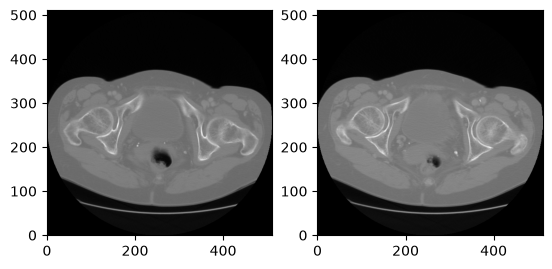

In [10]:

image_data = nib.load('./dataset/train/images/liver_0.nii.gz').get_fdata()
slices = np.array([image_data[:, :, 10], image_data[:, :, 11]])
show_slices(slices)
slices.shape

# PreProcessing

In [11]:
path_training_images = sorted(glob(os.path.join(SOURCE_DATASET_IMG, '*.nii.gz')))
path_training_segmentation = sorted(glob(os.path.join(SOURCE_DATASET_LABELS, '*.nii.gz')))

path_test_images = sorted(glob(os.path.join(SOURCE_DATASET_TEST, 'images', '*.nii.gz')))
path_test_segmentation = sorted(glob(os.path.join(SOURCE_DATASET_TEST, 'labels', '*.nii.gz')))

train_files = [
    {
        "vol": image_name,
        "seg": label_name
    } for image_name, label_name in zip(path_training_images, path_training_segmentation)
]

test_files = [
    {
        "vol": image_name,
        "seg": label_name
    } for image_name, label_name in zip(path_test_images, path_test_segmentation)
]

In [12]:
from monai.transforms import (
    Compose, 
    LoadImaged,
    EnsureTyped, 
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    CropForegroundd,
    Resized,
    ToTensord
)

from monai.data import (
    DataLoader,
    Dataset,
    load_decathlon_datalist
)

# from torch.utils.data import DataLoader
from monai.utils import set_determinism

min_slices = 64
pixdim=(1.5, 1.5, 1.0)
a_min = -200
a_max = 200
spatial_size = (128,128, min_slices)
set_determinism(seed=1)

train_transforms = Compose([
    LoadImaged(keys = ['vol', 'seg']),
    EnsureChannelFirstd(keys = ['vol', 'seg']),

    # EnsureTyped(keys=["seg"], dtype=np.int64),

    Spacingd(keys =['vol', 'seg'], pixdim = pixdim, mode=("bilinear", "nearest") ),
    Orientationd(keys =['vol', 'seg'], axcodes = "RAS"),
    ScaleIntensityRanged(keys=["vol"], a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys =['vol', 'seg'], source_key='vol'),
    Resized(keys =['vol', 'seg'], spatial_size=spatial_size, mode=("trilinear", "nearest")),
    ToTensord(keys=["vol", "seg"]),
])

valid_transforms = Compose([
    LoadImaged(keys = ['vol', 'seg']),
    EnsureChannelFirstd(keys = ['vol', 'seg']),
    Spacingd(keys =['vol', 'seg'], pixdim = pixdim, mode=("bilinear", "nearest") ),
    Orientationd(keys =['vol', 'seg'], axcodes = "RAS"),
    ScaleIntensityRanged(keys=["vol"], a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys =['vol', 'seg'], source_key='vol'),
    Resized(keys =['vol', 'seg'], spatial_size=spatial_size, mode=("trilinear", "nearest")),
    ToTensord(keys=["vol", "seg"]),
])



/Users/rojankarki/Projects/LearningML/cancer-imaging/.venv/lib/python3.14/site-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [15]:
train_ds = Dataset(
    data=train_files,
    transform=train_transforms
    )
train_loader= DataLoader(train_ds, batch_size = 1)
test_ds = Dataset(
    data=test_files,
    transform=valid_transforms
)
test_loader = DataLoader(test_ds, batch_size = 1)


# TRAIN MODEL 

In [ ]:
from monai.networks.nets import Unet
from monai.networks.layers import Norm

base = 16
channels = tuple(base * int(math.pow(2, x)) for x in range(5))
strides = (2, 2, 2, 2)
model = Unet(
    spatial_dims=len(spatial_size),
    in_channels=1,
    out_channels=2,
    channels=channels,
    strides=strides,
    num_res_units=2,
    norm=Norm.BATCH  
)

In [ ]:
from monai.losses import DiceLoss
loss_function = DiceLoss(softmax=True, squared_pred=True, to_onehot_y= True)

In [ ]:
import torch
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5, amsgrad=True)

In [ ]:
def train(model, train_loader, test_loader, loss, optim, epochs, model_dir='model/'):
    os.makedirs(model_dir, exist_ok=True)
    train_loss = []
    best_metric = -1
    best_epoch = 0
    valid_loss = []
    train_metric = []
    valid_metric = []

    for epoch in range(epochs):
        #loss per sample in batch
        print(f"Epoch: {epoch} {'-'*20}")   
        train_epoch_loss, train_epoch_metric = train_one_epoch(model, train_loader, loss, optim)
        train_loss.append(train_epoch_loss)
        train_metric.append(train_epoch_metric)

        print(f'Training loss: {train_epoch_loss:.4f}')
        print(f'Training metric: {train_epoch_metric:.4f}')

        valid_epoch_loss, valid_epoch_metric = validate(model, test_loader, loss, optim)
        valid_loss.append(valid_epoch_loss)
        valid_metric.append(valid_epoch_metric)

        print(f'Validation loss: {valid_epoch_loss:.4f}')
        print(f'Validation metric: {valid_epoch_metric:.4f}')

        if valid_epoch_metric > best_metric:
            best_metric = valid_epoch_metric
            best_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join( model_dir, "best_metric_model.pth"))

    print("Training Completed")


In [ ]:
def train_one_epoch(model, train_loader, loss, optim):
    model.train()
    train_epoch_loss = 0
    train_epoch_metric = 0
    train_steps = 0
    for batch in train_loader:
        train_steps += 1
        volume, label = batch['vol'], batch['seg']
        # label = label != 0 # convert labels into bool mask, all values other than 0 is True

        # label[label > 0] = 1
        optim.zero_grad()

        output = model(volume)
        train_loss = loss(output, label)
        train_loss.backward()
        optim.step()

        train_epoch_loss += train_loss.item()
        
        dice_metric = 1-train_loss.item()
        train_epoch_metric += dice_metric

    train_epoch_loss /= train_steps
    train_epoch_metric /= train_steps

    return train_epoch_loss, train_epoch_metric
    


In [ ]:
batch = next(iter(train_loader))
# batch = next(iter(train_loader))

labels = batch['seg']
np.unique(labels)

array([0.       , 0.9960785, 2.       ], dtype=float32)

In [ ]:
def validate(model, test_loader, loss, optim):
    # validation
    model.eval()
    with torch.no_grad():
        valid_epoch_loss = 0
        valid_epoch_metric = 0
        valid_step = 0

        for batch in test_loader:
            valid_step += 1
            volume, label = batch['vol'], batch['seg']
            output = model(volume)
            valid_loss = loss(output, label)
            valid_epoch_loss += valid_loss.item()
            valid_metric = 1-valid_loss.item()
            valid_epoch_metric += valid_metric

        # validation loss per sample
        valid_epoch_loss /= valid_step
        valid_epoch_metric /= valid_step
        return valid_epoch_loss, valid_epoch_metric


# VISUALIZE